## Embedding exploration

the purpose of this notebook is to explore where different samples of the model states/obs end up once embedded into diffusion space.

In [4]:
import numpy as np 
import sys
sys.path.insert(0,'..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh

reload(dap)

np.set_printoptions(suppress=True)


In [5]:
uoep = {'mu': 0, 'sigma': 1}
poep = {'mu': 0, 'sigma': 1} 
fice_uoep = {'mu': 0, 'sigma': 0.1, 'lnmu': 0, 'lnsigma': 1, 'lnscale': 30 } 
fice_t_params = {
    'a': 2, 'shift': 0.0, 'h_noise':0.0, 'v_noise':0.0, 'Nx':120, 'bound':3}
fice_e_params = {
    'a': 10, 'shift': 0.0,'h_noise':0.4, 'v_noise':0.0, 'Nx':120, 'bound': 3}
lfice_t_params = {
    'v_noise':0.01, 'Nx':120, 'f':1/2}
lfice_e_params = {
    'v_noise':0.0, 'Nx':120, 'f':1/2}
pfice_t_params = {
          'a1':10, 'a2':3, 'roll':0, 'v_noise':0.01, 'Nx':100}
pfice_e_params = {
          'a1':10, 'a2':3, 'roll':0, 'v_noise':0.0, 'Nx':100}
stagger_params = {
          'v_noise':0.01, 'Nx':120}


#fice_poep = {'mu': 0, 'sigma': 0.3, 'lnmu': 0, 'lnsigma': 1, 'lnscale': 30 }  
#poep = {'mu': 0}

DB: Starting cycle 0
DB: Starting cycle 100


<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L96: Direct p(y|x), Small Training'}, xlabel='$y$', ylabel='$p(y | x)$'>

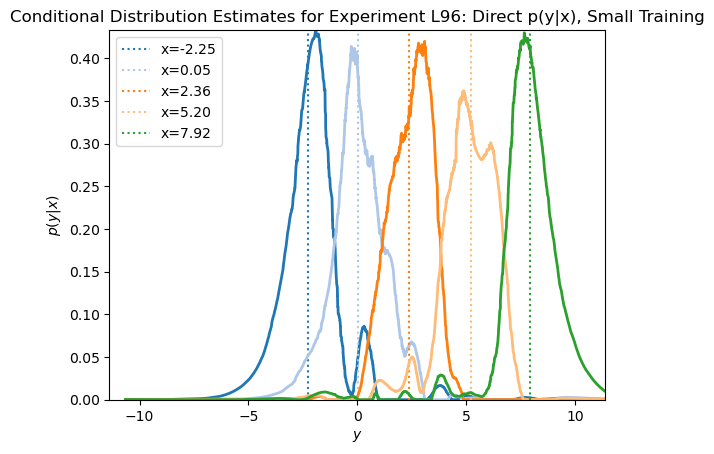

<Figure size 640x480 with 0 Axes>

In [12]:
#bad: 0.2 0.2
#good, 0.1 0.01
bw = 0.01
knn = 0.05
klb=0.0
e_small_training = dap.Expt('L96: Direct p(y|x), Small Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 101,
                       'T_train': 100,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
    #dap.saveExpt('.', e) 
dap.runDA(e_small_training)
fig, ax = plt.subplots()
dap.plot_pab(e_small_training, ax=ax, plot_states=True)
#   fig.savefig(f'{e_name}.png')
#   plt.close()
#   dest = f't{i}.mat'
#   !mkdir ../experiments/temp
#   #!mv {e_name}.expt ../experiments/$e_name
#   #!mv {e_name}.png ../experiments/$e_name
#   !mv training.mat ../experiments/$dest

AttributeError: 'Axes' object has no attribute 'plot3D'

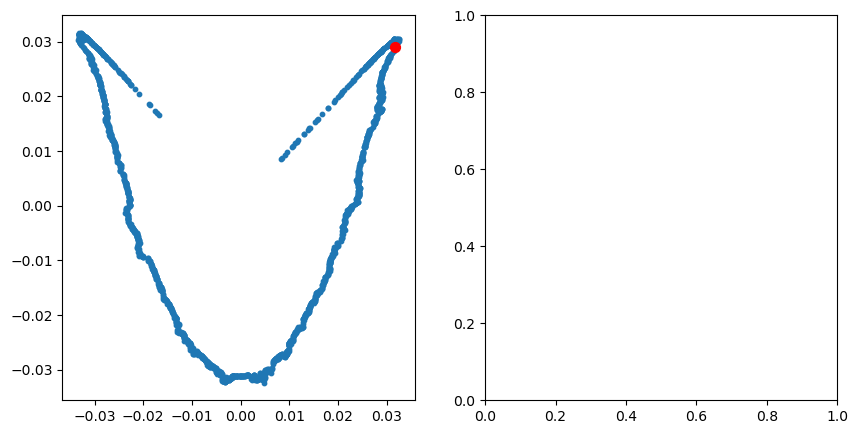

In [25]:
data = np.load('data/direct_v_nearest_pyx_calc/gauss_maps_100.npz')

x_train = data['x_train']
y_train = data['y_train']
evec_x, eval_x, a_train_x, bwx = data['evec_x'],data['eval_x'],data['a_train_x'],data['bwx']
evec_y, eval_y, a_train_y, bwy = data['evec_y'],data['eval_y'],data['a_train_y'],data['bwy']

x_emb = (evec_x * eval_x).T
y_emb = (evec_y * eval_y).T

Nx = e_small_training.getParam('Nx')
Nb = e_small_training.getParam('Nb')
x_dom = np.linspace(-fice_t_params['bound'], fice_t_params['bound'], fice_t_params['Nx']) 
model_flag = e_small_training.getParam('model_flag')

ts = np.linspace(0, 2*np.pi, Nx)
xs, ys = np.cos(ts), np.sin(ts)

plot_x=True
plot_3d=False
plot_oma=True
ind=30
for ind in range(2*Nb,Nx-2*Nb):
    ind = -ind    
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(1,2,1)
    if plot_3d:
        ax2 = fig.add_subplot(1,2,2, projection='3d')
    else:
        ax2 = fig.add_subplot(1,2,2)
    if plot_x:
        im = ax1.scatter(x_emb[1], x_emb[2], s=10)
    else:
        im = ax1.scatter(y_emb[1], y_emb[2], s=10)
    Nb=e_small_training.getParam('Nb')
    if plot_x:
        ax1.scatter(x_emb[1,ind], x_emb[2,ind], c='red', s=50)
    else:
        ax1.scatter(y_emb[1,ind], y_emb[2,ind], c='red', s=50)
    if plot_x:
        dap.plotExpt(e_small_training, 99, ax2, plotEns=False, plotObs=False)
    else:
        dap.plotExpt(e_small_training, 99, ax2, plotEns=False, plotObs=True)
    if plot_3d:
        if plot_x:
            if Nb == 0:
                ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], x_train[:,ind], c='red', zorder=10)
            else:
                ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], x_train[:,ind], c='red', zorder=10)
        else:
            if Nb == 0:
                if plot_oma:
                    ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind] + x_train[:,ind], c='red', zorder=10)
                else:
                    ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind] , c='red', zorder=10)
            else:
                if plot_oma:
                    ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind]+x_train[:,ind], c='red', zorder=10)
                else:
                    ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind], c='red', zorder=10)
    else:
        if model_flag == 4:
            plotx= x_dom
        else:
            plotx = np.arange(0,Nx,1)
        if plot_x:
            ax2.scatter(plotx[ind],x_train[:,ind], c='red', zorder=10, s=50)
        else:
            if plot_oma:
                ax2.scatter(plotx[ind],y_train[:,ind] +x_train[:,ind], c='red', zorder=10, s=50)
                ax2.vlines(plotx[ind], x_train[:,ind], y_train[:,ind] + x_train[:,ind], color='red', lw=5, zorder=10)
            else:
                ax2.scatter(plotx[ind],y_train[:,ind], c='red', zorder=10, s=50)
    ax1.set_xlabel('$\\phi_1$')
    ax1.set_ylabel('$\\phi_2$')
    ax1.set_title('Diffusion Map Embedding of $x$ - \"Discrete\" Ice Model')
    ax2.set_ylabel('Model State')
    ax2.set_xticks([])
    ax2.set_title('Original State $x$')
    

    fig.savefig(f'gif_figs/stagger/x_emb/stagger_embedding_x{-ind:03d}.png')
    plt.close()
